 # **BANK FRAUD DETECTION MACHINE LEARNING**
 ### - *BY ANANYA MISHRA*

### *achieved a solid **99.9%** accuracy in prediction* 

In [ ]:
#IMPORTING NECESSARY LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# **DATAFRAME**- *SHAPE, DESCRIPTION, HANDLING NULL,UNIQUE VALUES*

In [2]:
#LOADING DATASET
df=pd.read_csv('Fraud.csv')
df.head(15)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [5]:
#SHAPE OF DATASET
print('ROWS AND COLUMNS OF THE DATA ARE: ',df.shape)

ROWS AND COLUMNS OF THE DATA ARE:  (6362620, 11)


In [6]:
#EXTRACTING COLUMNS
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
#INFORMATION AND DESCRIPTION OF DATA
df.info()
print('\n')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB




,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


# *Checking Null Values*

In [8]:
#CHECKING NULL VALUES
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.isnull().sum().sum()

0

- 'Type column has 5 category, which we can either encode or just rename'

In [10]:
#UNIQUE VALUES
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [11]:
temp=df['type'].value_counts()
print(temp)


CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64


In [12]:
pi1=temp.index  #transpose
print(pi1)

Index(['CASH_OUT', 'PAYMENT', 'CASH_IN', 'TRANSFER', 'DEBIT'], dtype='object')


In [13]:
pi2=temp.values
print(pi2)

[2237500 2151495 1399284  532909   41432]


# *DATA VISUALIZATION/ ANALYSIS*

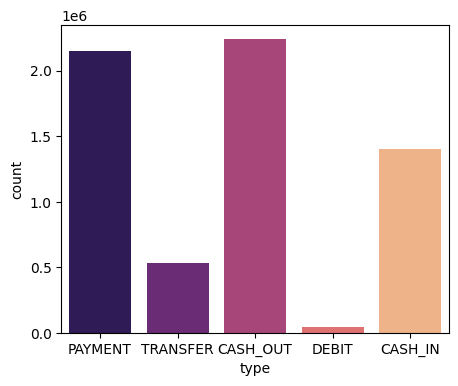

In [14]:
#VISUALIZATIONS OF DATA
plt.figure(figsize=(5,4))
sns.countplot(x="type",data=df,palette='magma')
plt.show()

In [15]:
y = df['isFraud']

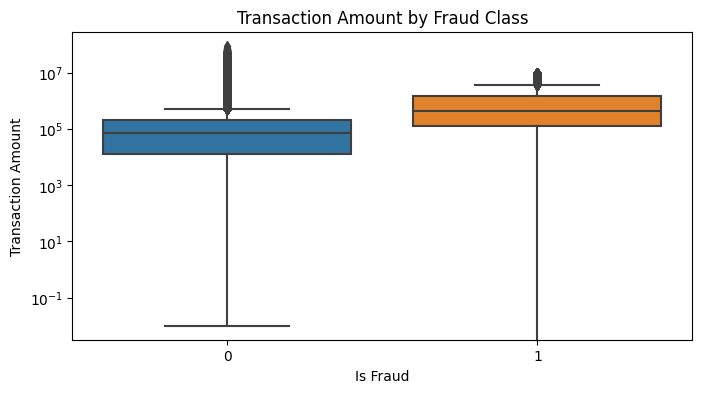

In [16]:

import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=y, y=df['amount'])
plt.title('Transaction Amount by Fraud Class')
plt.yscale('log')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')
plt.show()

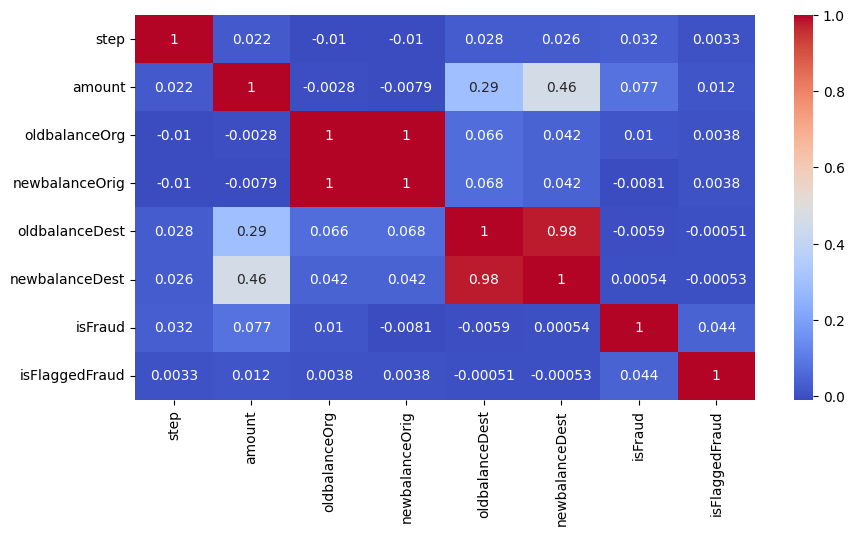

In [17]:
#CORRELATION MATRIX
cor=df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(cor,annot=True,cmap='coolwarm')
plt.show()

In [18]:
df['isFraud']=df['isFraud'].map({0:'NOT A FRAUD',1:'FRAUD'})
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,NOT A FRAUD,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,NOT A FRAUD,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,FRAUD,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,FRAUD,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,NOT A FRAUD,0


In [19]:
df.replace(to_replace=['PAYMENT', 'CASH_OUT', 'CASH_IN', 'TRANSFER', 'DEBIT'],value=[5,4,3,2,1],inplace=True)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,5,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,NOT A FRAUD,0
1,1,5,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,NOT A FRAUD,0
2,1,2,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,FRAUD,0
3,1,4,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,FRAUD,0
4,1,5,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,NOT A FRAUD,0


# *TRAIN, TEST, SPLITTING OF DATA*

## Columns/ Features to work on
- ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [21]:
features=['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
X = df.loc[:, features]                       #determining features needed for prediction
y = df.loc[:, ['isFraud']]

In [22]:
X.head(10)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,5,9839.64,170136.00,160296.36,0.0,0.00
1,5,1864.28,21249.00,19384.72,0.0,0.00
2,2,181.00,181.00,0.00,0.0,0.00
3,4,181.00,181.00,0.00,21182.0,0.00
4,5,11668.14,41554.00,29885.86,0.0,0.00
5,5,7817.71,53860.00,46042.29,0.0,0.00
6,5,7107.77,183195.00,176087.23,0.0,0.00
7,5,7861.64,176087.23,168225.59,0.0,0.00
8,5,4024.36,2671.00,0.00,0.0,0.00
9,1,5337.77,41720.00,36382.23,41898.0,40348.79


In [23]:
y.head(10)

,isFraud
0,NOT A FRAUD
1,NOT A FRAUD
2,FRAUD
3,FRAUD
4,NOT A FRAUD
5,NOT A FRAUD
6,NOT A FRAUD
7,NOT A FRAUD
8,NOT A FRAUD
9,NOT A FRAUD


# TRAIN TEST SPLIT DATSET

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)  
 
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape)

Shape of training set: (4453834, 6)
Shape of test set: (1908786, 6)


# - MODEL USED: **DECISION TREE CLASSIFIER**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
tree = DecisionTreeClassifier(class_weight='balanced', random_state=42) #weighted class to handle imbalance data
tree.fit(X_train, y_train)
print(tree.score(X_test, y_test))



0.9997040003436739


- Classification report

In [27]:
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       FRAUD       0.90      0.87      0.88      2435
 NOT A FRAUD       1.00      1.00      1.00   1906351

    accuracy                           1.00   1908786
   macro avg       0.95      0.93      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786



# MODEL TESTING AND PREDICTION

- TEST 1

In [31]:
model.predict([[5,9839.64,170136.00,160296.36,0.0,0.00]])

c:\Users\any\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['NOT A FRAUD'], dtype=object)

- TEST 2

In [ ]:
#ENTRY 3
model.predict([[4,181.00,181.00,0.00,21182.0,0.00]])

c:\Users\any\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['FRAUD'], dtype=object)

In [33]:
X.tail(3)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
6362617,4,6311409.28,6311409.28,0.0,68488.84,6379898.11
6362618,2,850002.52,850002.52,0.0,0.00,0.00
6362619,4,850002.52,850002.52,0.0,6510099.11,7360101.63


In [34]:
y.tail(3)

,isFraud
6362617,FRAUD
6362618,FRAUD
6362619,FRAUD


- TEST 3

In [28]:
#ENTRY 2
tree.predict([[2,850002.52,850002.52,0.0,0.00,0.00]])

c:\Users\any\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['FRAUD'], dtype=object)

In [30]:
tree.predict([[5,7861.64,176087.23,168225.59,0.0,0.00]])  #entry 7

c:\Users\any\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['NOT A FRAUD'], dtype=object)

- TEST 4

In [31]:
# ROW 4
tree.predict([[5,11668.14,41554.00,29885.86,0.0,0.00]])

c:\Users\any\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['NOT A FRAUD'], dtype=object)

CONFUSION MATRIX

In [32]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[   2114     321]
 [    244 1906107]]


- TRUE NEGATIVE -> 2114 (actual non fraud, predicted non fraud)
- TRUE POSITIVE -> 1906107 (actual Fraud, Predicted Fraud)
- FALSE POSITIVE -> 321 (actual Non Fraud, Predicted Fraud)
- FALSE NEGATIVE -> 244 (Aactual Fraud, Predicted Non Fraud)

In [ ]:
tree.fit(X_train, y_train)
accuracy= tree.score(X_test,y_test)

print(f"Accuracy: {accuracy * 100:.4f}%") # upto 4 decimal places

Accuracy: 99.9704%
